## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re, sklearn, string, sys, tensorflow, time
from random import randint
from keras import backend as K, regularizers, optimizers
from keras.models import load_model, Sequential
from keras.layers import MaxPooling2D, Convolution2D, Activation, Dropout, Flatten, Dense, InputLayer
from keras.layers.normalization import BatchNormalization
from keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.utils import np_utils
from sklearn.model_selection import train_test_split
import tensorflow as tf
tf.set_random_seed(42)
import keras
from keras.layers import Dense
import matplotlib.pyplot as plt
from keras.preprocessing import image

print('Keras version: \t\t%s' % keras.__version__)
print('Scikit version: \t%s' % sklearn.__version__)
print('TensorFlow version: \t%s' % tensorflow.__version__)

Using TensorFlow backend.


Keras version: 		2.2.4
Scikit version: 	0.21.3
TensorFlow version: 	1.14.0


In [0]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

### Find no.of samples are there in training and test datasets

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
y_train.shape

(60000,)

In [5]:
x_test.shape

(10000, 28, 28)

In [6]:
y_test.shape

(10000,)

### Find dimensions of an image in the dataset

In [7]:
x_train[0,:,:].shape

(28, 28)

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

In [11]:
x_train.shape

(60000, 28, 28, 1)

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [12]:
#Initialize sequential model
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(32, #Number of filters 
                                kernel_size=(3,3), #Size of the filter
                                activation='relu'))

#Add second convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
#Flatten the output
model.add(tf.keras.layers.Flatten())
#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))
#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))
#Complie the model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
#model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test),batch_size=32)

W0818 12:38:08.530986 140000404420480 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [13]:
#Initialize sequential model
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(32, #Number of filters 
                                kernel_size=(3,3), #Size of the filter
                                activation='relu'))

#Add second convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
# Conv + Maxpooling
#model.add(Convolution2D(32, (2, 2), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model.add(tf.keras.layers.Dropout(0.25))
#Flatten the output
model.add(tf.keras.layers.Flatten())
#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))
#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))
#Complie the model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test),batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 9s 155us/sample - loss: 0.3886 - acc: 0.8598 - val_loss: 0.2997 - val_acc: 0.8924
Epoch 2/10
60000/60000 [==============================] - 7s 119us/sample - loss: 0.2551 - acc: 0.9060 - val_loss: 0.2523 - val_acc: 0.9090
Epoch 3/10
60000/60000 [==============================] - 7s 120us/sample - loss: 0.2073 - acc: 0.9227 - val_loss: 0.2506 - val_acc: 0.9098
Epoch 4/10
60000/60000 [==============================] - 7s 119us/sample - loss: 0.1764 - acc: 0.9337 - val_loss: 0.2251 - val_acc: 0.9185
Epoch 5/10
60000/60000 [==============================] - 7s 118us/sample - loss: 0.1488 - acc: 0.9439 - val_loss: 0.2329 - val_acc: 0.9200
Epoch 6/10
60000/60000 [==============================] - 7s 114us/sample - loss: 0.1251 - acc: 0.9532 - val_loss: 0.2493 - val_acc: 0.9185
Epoch 7/10
60000/60000 [==============================] - 7s 116us/sample - loss: 0.1069 - acc: 0.9598 - val_l

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
datagen = ImageDataGenerator()

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

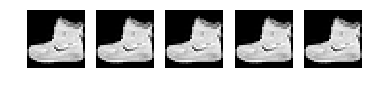

In [15]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [16]:
datagen.fit(x_train)
model.fit_generator(datagen.flow(x_train, y_train, batch_size=32), steps_per_epoch=len(x_train) / 32,validation_data=(x_test,y_test), epochs=20) 

Epoch 1/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0641 - acc: 0.9764 - val_loss: 0.3260 - val_acc: 0.9213
Epoch 2/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0571 - acc: 0.9788 - val_loss: 0.3262 - val_acc: 0.9223
Epoch 3/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0507 - acc: 0.9816 - val_loss: 0.3260 - val_acc: 0.9221
Epoch 4/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0474 - acc: 0.9823 - val_loss: 0.3633 - val_acc: 0.9228
Epoch 5/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0417 - acc: 0.9855 - val_loss: 0.3787 - val_acc: 0.9229
Epoch 6/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0423 - acc: 0.9844 - val_loss: 0.3693 - val_acc: 0.9230
Epoch 7/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0397 - acc: 0.9857 - val_loss: 0.3888 - val_acc: 0.9239
Epoch 8/20
1875/1875 [==============================] -

###  Report the final train and validation accuracy

In [17]:
# Evaluate the model on test set
score = model.evaluate(x_test, y_test, verbose=0)

# Print test accuracy
print('\n', 'Test accuracy:', score[1])


 Test accuracy: 0.9231


In [18]:
# Evaluate the model on train set
score2 = model.evaluate(x_train, y_train, verbose=0)
# Print test accuracy
print('\n', 'Train accuracy:', score2[1])


 Train accuracy: 0.99831665


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

### **Load CIFAR10 dataset**

In [0]:
from keras.datasets import cifar10
(x_train1, y_train1), (x_test1, y_test1) = cifar10.load_data()

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
datagen1 = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True,
                                                               width_shift_range=0.2,
                                                               height_shift_range=0.2,
                                                               rotation_range=30)

### **Prepare/fit the generator.**

In [0]:
datagen1.fit(x_train1)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

In [0]:
x_train1 = x_train1.astype('float32') / 255
x_test1 = x_test1.astype('float32') / 255

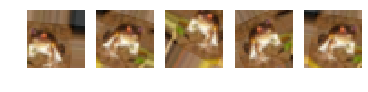

In [39]:
from matplotlib import pyplot as plt
gen = datagen1.flow(x_train1[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()